## Import data and plot

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
    MeanShift,
    estimate_bandwidth,
)
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [12]:
points = pd.read_csv("Painted_data.csv")
points = points.iloc[2:, :].astype(float).copy()
points.columns = ["x", "y"]
points.head()

,x,y
2,0.213214,0.682323
3,0.196110,0.623509
4,0.271655,0.592002
5,0.234595,0.684423
6,0.512543,0.839860


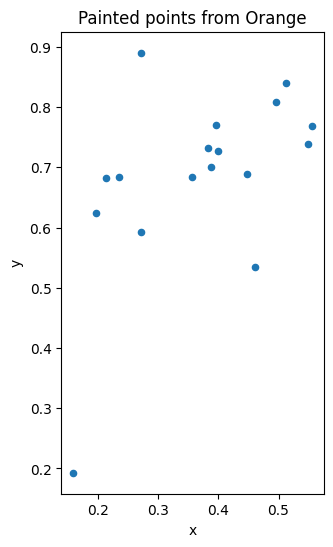

In [15]:
ax = points.plot.scatter(
    x="x",
    y="y",
    figsize=(6, 6),
    title="Painted points from Orange",
)
ax.set_aspect("equal")
plt.show()


## DBSCAN

In [16]:
span = max(
    points["x"].max() - points["x"].min(),
    points["y"].max() - points["y"].min(),
)
eps = span / 8
print(f"DBSCAN eps: {eps:.2f}")

DBSCAN eps: 0.09


In [17]:
dbscan = DBSCAN(eps=eps, min_samples=3)
labels_db = dbscan.fit_predict(points)
dbscan_result = points.copy()
dbscan_result["dbscan_cluster"] = labels_db
dbscan_result.head()

,x,y,dbscan_cluster
2,0.213214,0.682323,0
3,0.196110,0.623509,0
4,0.271655,0.592002,0
5,0.234595,0.684423,0
6,0.512543,0.839860,1


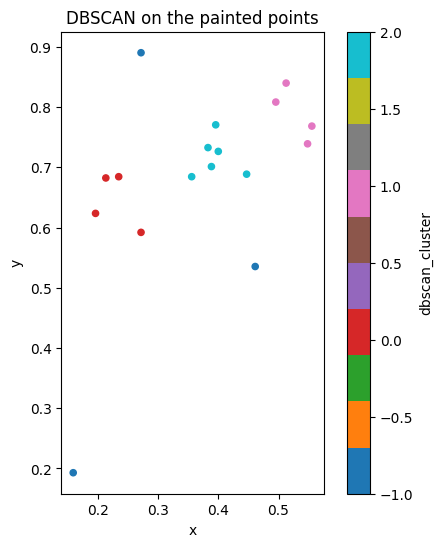

In [18]:
ax = dbscan_result.plot.scatter(
    x="x",
    y="y",
    c="dbscan_cluster",
    cmap="tab10",
    figsize=(6, 6),
    title="DBSCAN on the painted points",
)
ax.set_aspect("equal")
plt.show()


In [19]:
mask = labels_db != -1
print("DBSCAN labels:", sorted(set(labels_db)))
print("Noise points:", int((labels_db == -1).sum()))
if mask.sum() and len(set(labels_db[mask])) > 1:
    score = silhouette_score(points.loc[mask, ["x", "y"]], labels_db[mask])
    print(f"DBSCAN silhouette (non-noise only): {score:.2f}")
else:
    print("Need at least two non-noise clusters before silhouette makes sense.")

DBSCAN labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Noise points: 3
DBSCAN silhouette (non-noise only): 0.59


## K-means

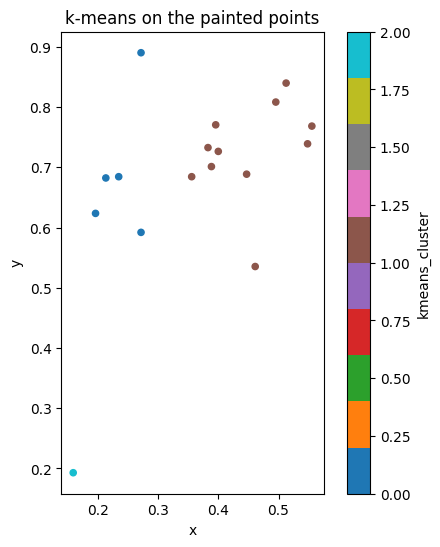

k-means labels: [np.int32(0), np.int32(1), np.int32(2)]
k-means silhouette: 0.41


In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(points)
kmeans_result = points.copy()
kmeans_result["kmeans_cluster"] = labels_km
ax = kmeans_result.plot.scatter(
    x="x",
    y="y",
    c="kmeans_cluster",
    cmap="tab10",
    figsize=(6, 6),
    title="k-means on the painted points",
)
ax.set_aspect("equal")
plt.show()
print("k-means labels:", sorted(set(labels_km)))
print(f"k-means silhouette: {silhouette_score(points, labels_km):.2f}")


## Mean-shift

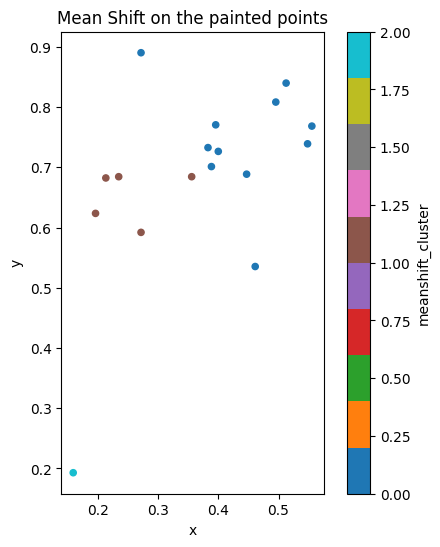

Mean Shift bandwidth: 0.14
Mean Shift labels: [np.int64(0), np.int64(1), np.int64(2)]
Mean Shift silhouette: 0.35


In [21]:
bandwidth = estimate_bandwidth(points, quantile=0.3, n_samples=len(points))
if bandwidth <= 0:
    bandwidth = span / 6
mean_shift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = mean_shift.fit_predict(points)
mean_shift_result = points.copy()
mean_shift_result["meanshift_cluster"] = labels_ms
ax = mean_shift_result.plot.scatter(
    x="x",
    y="y",
    c="meanshift_cluster",
    cmap="tab10",
    figsize=(6, 6),
    title="Mean Shift on the painted points",
)
ax.set_aspect("equal")
plt.show()
print(f"Mean Shift bandwidth: {bandwidth:.2f}")
print("Mean Shift labels:", sorted(set(labels_ms)))
if 1 < len(set(labels_ms)) < len(points):
    print(f"Mean Shift silhouette: {silhouette_score(points, labels_ms):.2f}")
else:
    print("Mean Shift found one cluster, so silhouette is not useful.")


## Hierarchical

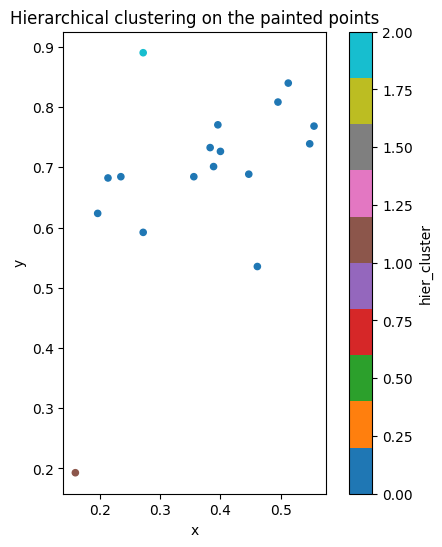

Hierarchical labels: [np.int64(0), np.int64(1), np.int64(2)]
Hierarchical silhouette: 0.25


In [26]:
hier = AgglomerativeClustering(n_clusters=3, linkage="single")
labels_hier = hier.fit_predict(points)
hier_result = points.copy()
hier_result["hier_cluster"] = labels_hier
ax = hier_result.plot.scatter(
    x="x",
    y="y",
    c="hier_cluster",
    cmap="tab10",
    figsize=(6, 6),
    title="Hierarchical clustering on the painted points",
)
ax.set_aspect("equal")
plt.show()
print("Hierarchical labels:", sorted(set(labels_hier)))
print(f"Hierarchical silhouette: {silhouette_score(points, labels_hier):.2f}")


## Stretched

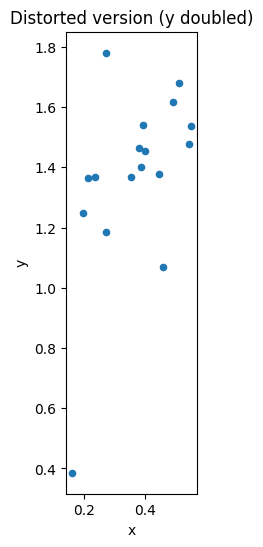

DBSCAN on stretched data: [np.int64(-1), np.int64(0)]
k-means on stretched data: [np.int32(0), np.int32(1), np.int32(2)]


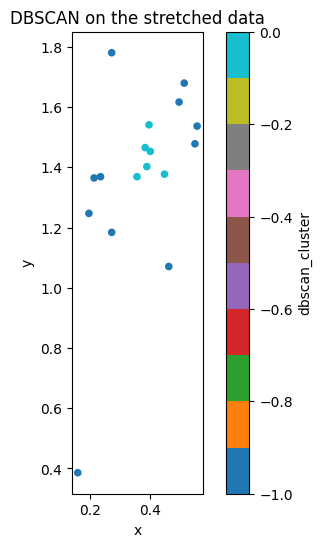

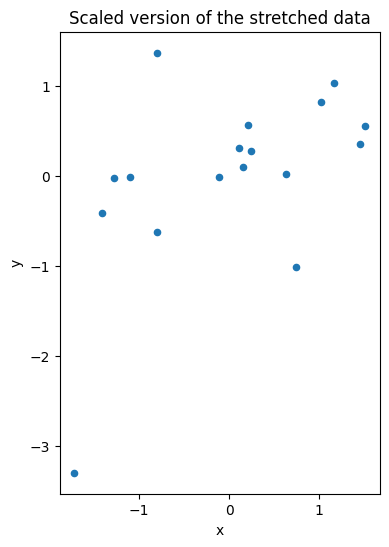

DBSCAN on scaled data: [np.int64(-1), np.int64(0), np.int64(1)]
k-means on scaled data: [np.int32(0), np.int32(1), np.int32(2)]


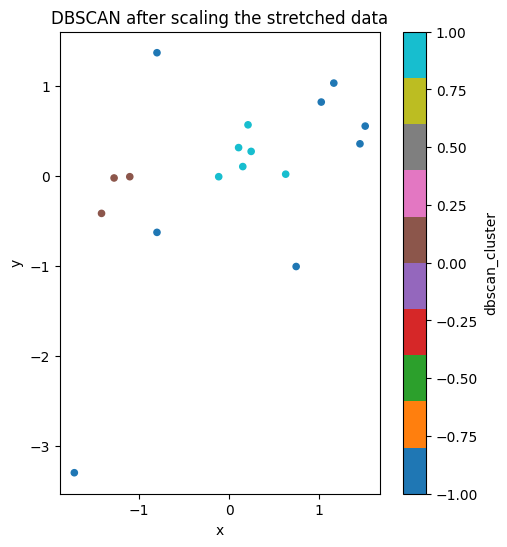

In [28]:
stretched = points.copy()
stretched["y"] = stretched["y"] * 2
ax = stretched.plot.scatter(
    x="x",
    y="y",
    figsize=(6, 6),
    title="Distorted version (y doubled)",
)
ax.set_aspect("equal")
plt.show()
labels_db_stretched = DBSCAN(eps=eps, min_samples=3).fit_predict(stretched)
labels_km_stretched = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10,
).fit_predict(stretched)

print("DBSCAN on stretched data:", sorted(set(labels_db_stretched)))
print("k-means on stretched data:", sorted(set(labels_km_stretched)))
stretched_dbscan = stretched.copy()
stretched_dbscan["dbscan_cluster"] = labels_db_stretched
ax = stretched_dbscan.plot.scatter(
    x="x",
    y="y",
    c="dbscan_cluster",
    cmap="tab10",
    figsize=(6, 6),
    title="DBSCAN on the stretched data",
)
ax.set_aspect("equal")
plt.show()
scaler = StandardScaler()
stretched_scaled_array = scaler.fit_transform(stretched)

stretched_scaled = pd.DataFrame(
    stretched_scaled_array,
    columns=["x", "y"],
)
ax = stretched_scaled.plot.scatter(
    x="x",
    y="y",
    figsize=(6, 6),
    title="Scaled version of the stretched data",
)
ax.set_aspect("equal")
plt.show()
labels_db_scaled = DBSCAN(eps=0.5, min_samples=3).fit_predict(stretched_scaled)
labels_km_scaled = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10,
).fit_predict(stretched_scaled)
print("DBSCAN on scaled data:", sorted(set(labels_db_scaled)))
print("k-means on scaled data:", sorted(set(labels_km_scaled)))
scaled_dbscan = stretched_scaled.copy()
scaled_dbscan["dbscan_cluster"] = labels_db_scaled
ax = scaled_dbscan.plot.scatter(
    x="x",
    y="y",
    c="dbscan_cluster",
    cmap="tab10",
    figsize=(6, 6),
    title="DBSCAN after scaling the stretched data",
)
ax.set_aspect("equal")
plt.show()
